# Nome: Wesley Rafael da Silva  RA: 625105397
# Turma: A Serie: 01 Turno: Noturno

Solução Apresentada Modelo Simples de CNN de dupla validação (Pedestrest e Não Pedestres) , pensando em uma arquitetura simples onde não podemos contar com modelos mais elaboradores ou que não tenhamos hardware a nossa disposição como os fornecidos pelo seu proprio dispositivo ou google Colab.
Ps: para verificação de um modelo mais elaborado compartilhei também o arquivo no link: https://colab.research.google.com/drive/1hIbCeODBhMC6YPEd9i86A1ZgXVH72yCJ?usp=sharing

onde foi utilizado modelo pre-treinado **Resnet18**

In [ ]:
# Importações
import os
import requests
import zipfile
from io import BytesIO
import random
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid


In [ ]:
# Configura dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [ ]:
# Diretórios temporários para os datasets

data_dir = './data_pedestrian'
pedestrian_dir = os.path.join(data_dir, 'pedestrians')
background_dir = os.path.join(data_dir, 'background')

os.makedirs(pedestrian_dir, exist_ok=True)
os.makedirs(background_dir, exist_ok=True)

In [ ]:
# Download e extração

def download_and_extract(url, extract_to):
    print(f"Baixando e extraindo de: {url}")
    response = requests.get(url)
    with zipfile.ZipFile(BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extraído em: {extract_to}")

In [ ]:
# URLs dos datasets
url_background = "https://www.dropbox.com/scl/fo/myx9nxbavqi073ll365qo/AJWKN4UAPvlIa5n8ZUHWST4/Background?rlkey=3h0kub8j36rthlwos741vh78h&dl=1"
url_pedestrians = "https://www.dropbox.com/scl/fo/myx9nxbavqi073ll365qo/AAPMm6XJI96pJd5QXC08toA/Pedestrians?rlkey=3h0kub8j36rthlwos741vh78h&dl=1"

In [ ]:
# Download e extração
download_and_extract(url_background, background_dir)
download_and_extract(url_pedestrians, pedestrian_dir)

Baixando e extraindo de: https://www.dropbox.com/scl/fo/myx9nxbavqi073ll365qo/AJWKN4UAPvlIa5n8ZUHWST4/Background?rlkey=3h0kub8j36rthlwos741vh78h&dl=1
Extraído em: ./data_pedestrian/background
Baixando e extraindo de: https://www.dropbox.com/scl/fo/myx9nxbavqi073ll365qo/AAPMm6XJI96pJd5QXC08toA/Pedestrians?rlkey=3h0kub8j36rthlwos741vh78h&dl=1
Extraído em: ./data_pedestrian/pedestrians


In [ ]:
# Organização dos Dados

dataset_dir = os.path.join(data_dir, 'dataset')
pedestrian_class_dir = os.path.join(dataset_dir, 'pedestrian')
background_class_dir = os.path.join(dataset_dir, 'background')

os.makedirs(pedestrian_class_dir, exist_ok=True)
os.makedirs(background_class_dir, exist_ok=True)

In [ ]:
# move imagens extraída para a pasta dataset/class_name
import shutil
def move_images(src_folder, dest_folder):
    count = 0
    for root, _, files in os.walk(src_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                src_file = os.path.join(root, file)
                dest_file = os.path.join(dest_folder, file)
                # Evita sobrescrever arquivos com mesmo nome
                if os.path.exists(dest_file):
                    base, ext = os.path.splitext(file)
                    dest_file = os.path.join(dest_folder, f"{base}_{count}{ext}")
                    count += 1
                shutil.move(src_file, dest_file)

print("Movendo imagens para pasta dataset/class...")
move_images(pedestrian_dir, pedestrian_class_dir)
move_images(background_dir, background_class_dir)

Movendo imagens para pasta dataset/class...


In [ ]:
# Transformações
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # normalização padrão ImageNet
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
# Carrega dataset com ajustes
full_dataset = datasets.ImageFolder(root=dataset_dir, transform=transform)
print(f"Total de imagens no dataset: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")

Total de imagens no dataset: 5406
Classes: ['background', 'pedestrian']


In [ ]:
# Divisão 70% treino, 15% validação, 15% teste

total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size],
                                                       generator=torch.Generator().manual_seed(42))

In [ ]:
# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
# Definição da CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # (batch,16,64,64)
            nn.ReLU(),
            nn.MaxPool2d(2),                            # (batch,16,32,32)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),# (batch,32,32,32)
            nn.ReLU(),
            nn.MaxPool2d(2),                            # (batch,32,16,16)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),# (batch,64,16,16)
            nn.ReLU(),
            nn.MaxPool2d(2),                            # (batch,64,8,8)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # 2 classes: pedestrian e background
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
#Validação da acurácia

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels).item() / len(labels)

# Otimizador e loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Treinamento com validação

num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_acc = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_acc += accuracy(outputs, labels) * inputs.size(0)

    train_loss /= train_size
    train_acc /= train_size

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_acc += accuracy(outputs, labels) * inputs.size(0)
    val_loss /= val_size
    val_acc /= val_size

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

Epoch 1/10: Train Loss=0.3299, Train Acc=0.8541 | Val Loss=0.1150, Val Acc=0.9667
Epoch 2/10: Train Loss=0.1344, Train Acc=0.9511 | Val Loss=0.1020, Val Acc=0.9654
Epoch 3/10: Train Loss=0.0976, Train Acc=0.9633 | Val Loss=0.0880, Val Acc=0.9642
Epoch 4/10: Train Loss=0.0561, Train Acc=0.9791 | Val Loss=0.0611, Val Acc=0.9765
Epoch 5/10: Train Loss=0.0457, Train Acc=0.9812 | Val Loss=0.0651, Val Acc=0.9753
Epoch 6/10: Train Loss=0.0371, Train Acc=0.9849 | Val Loss=0.1002, Val Acc=0.9605
Epoch 7/10: Train Loss=0.0368, Train Acc=0.9878 | Val Loss=0.0949, Val Acc=0.9704
Epoch 8/10: Train Loss=0.0267, Train Acc=0.9902 | Val Loss=0.0812, Val Acc=0.9704
Epoch 9/10: Train Loss=0.0257, Train Acc=0.9902 | Val Loss=0.0713, Val Acc=0.9778
Epoch 10/10: Train Loss=0.0043, Train Acc=0.9992 | Val Loss=0.0627, Val Acc=0.9802


In [ ]:
# Salva melhor modelo

if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print("Modelo salvo.")

Modelo salvo.


In [ ]:
# Relatório de Classificação e Matriz de Confusão

from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Relatório de Classificação no Teste:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

print("Matriz de Confusão:")
print(confusion_matrix(all_labels, all_preds))

Relatório de Classificação no Teste:
              precision    recall  f1-score   support

  background       0.98      0.99      0.98       475
  pedestrian       0.98      0.97      0.98       337

    accuracy                           0.98       812
   macro avg       0.98      0.98      0.98       812
weighted avg       0.98      0.98      0.98       812

Matriz de Confusão:
[[470   5]
 [ 11 326]]


In [ ]:
# Função para mostrar imagens com predição e label real

def imshow(img, title):
    img = img / 2 + 0.5     # desnormaliza
    npimg = img.numpy()
    plt.figure(figsize=(10,4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
def testar_classe(classe_nome, num_imagens=8):
    idxs = [i for i, (_, label) in enumerate(full_dataset) if full_dataset.classes[label] == classe_nome]
    sample_idxs = random.sample(idxs, min(num_imagens, len(idxs)))

    def label_customizado(label_str):
        if label_str.lower() == 'pedestrian':
            return "Pedestre"
        else:
            return "Não Pedestre"

    model.eval()
    with torch.no_grad():
        for idx in sample_idxs:
            img, label = full_dataset[idx]
            input_img = img.unsqueeze(0).to(device)
            output = model(input_img)
            _, pred = torch.max(output, 1)

            pred_label = full_dataset.classes[pred.item()]

            plt.figure(figsize=(4,4))
            plt.title(label_customizado(pred_label), fontsize=14)  # Mostra só a predição em pt-br

            # Desnormalizar para visualização correta
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            img_show = img * std + mean
            img_show = img_show.clamp(0,1)

            plt.imshow(np.transpose(img_show.numpy(), (1, 2, 0)))
            plt.axis('off')
            plt.show()


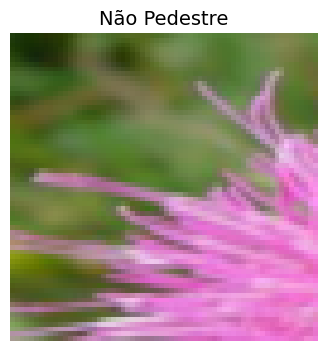

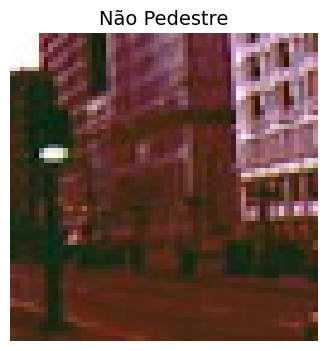

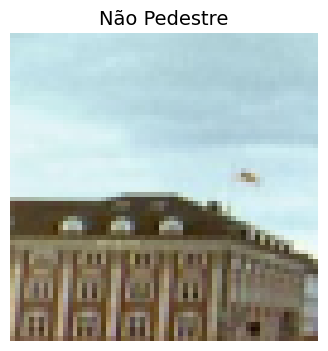

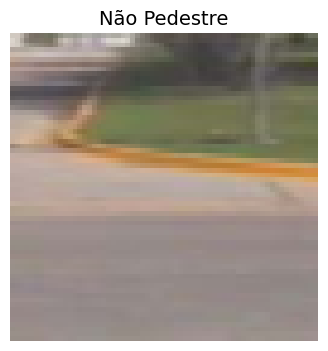

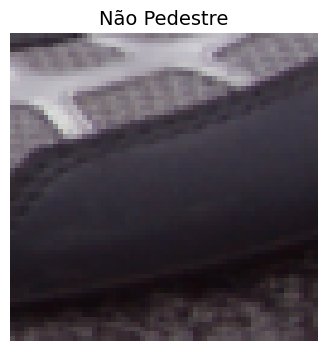

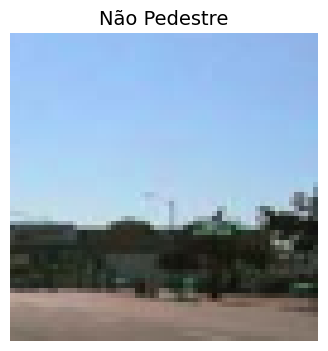

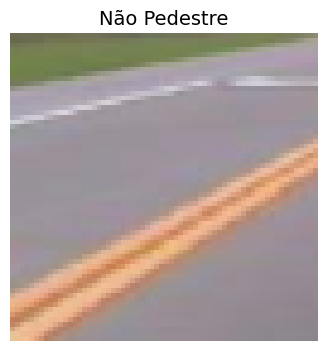

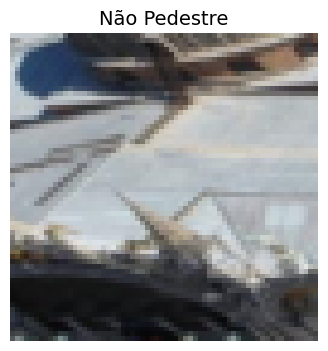

In [ ]:
testar_classe('background', num_imagens=8)


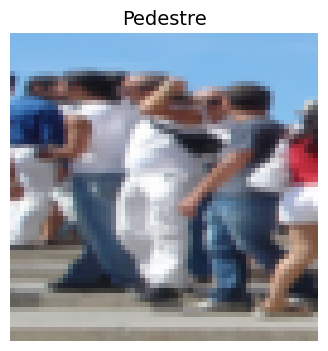

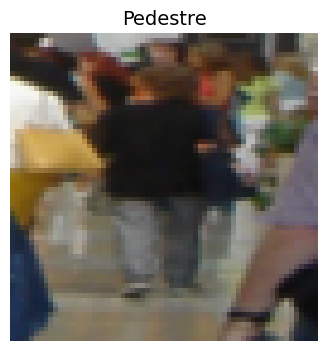

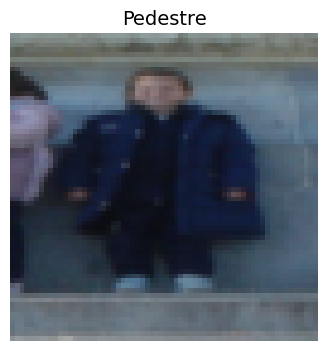

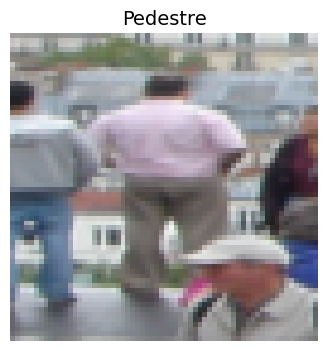

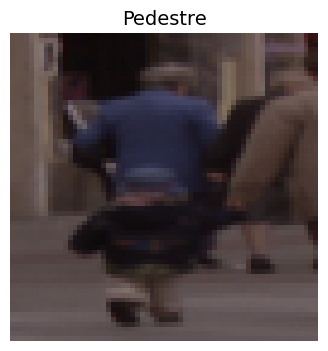

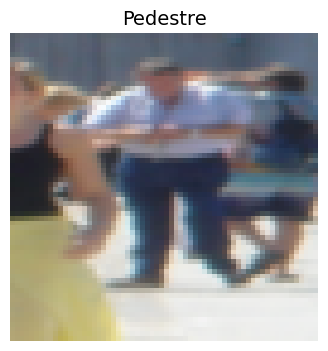

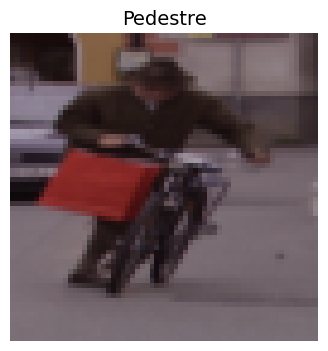

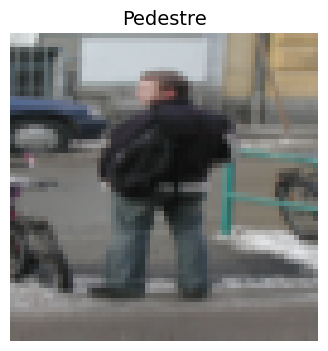

In [ ]:
testar_classe('pedestrian', num_imagens=8)